# Phase 3 — Fehlertaxonomie

**Ziel:** Die 30 Erklärungen mit dem niedrigsten kombinierten RA/SA-Score (Ichmoukhamedov-Metrik)
manuell einem Fehlercode zuordnen, die Kategorien beschreiben und Häufigkeiten auszählen.

**Methodik:** Für jeden Fall werden verglichen:
1. **Ground-Truth** — lokale SHAP-/EBM-Beiträge aus `explanations/local_*.json` (nach absolutem Beitrag sortiert)
2. **Generierte Erklärung** — Text aus `results/pipeline0{4,5,6}/*.json`
3. **Extraktion** — strukturiertes JSON aus `results/eval08_ichmoukhamedov/extractions.json`
   (was Notebook 08 aus der Erklärung herausgelesen hat)

Fehlerquelle kann entweder die **Erklärung selbst** oder der **LLM-basierte Extractor in NB 08** sein.

## 1  Taxonomie-Definitionen

| Code | Name | Beschreibung | Quelle |
|------|------|-------------|--------|
| **E1** | Extractor-Feature-Swap | Der NB-08-Extractor weist einer Erklärung das falsche Feature als Rang 0 zu, obwohl die Erklärung das korrekte Feature benennt. | Eval |
| **E2** | Extractor-Vorzeichen-Inversion | Der Extractor identifiziert das korrekte Feature am richtigen Rang, invertiert aber das Vorzeichen (positiver Beitrag → `sign=-1` oder umgekehrt). | Eval |
| **E3** | Extractor-Cross-Instance-Halluzination | Der Extractor extrahiert Kontext aus einem völlig anderen Szenario (andere Uhrzeit, anderer Wochentag, anderes Jahr) als die vorliegende Instanz. | Eval |
| **B1** | Positive/Negative-Gruppierung | Die Erklärung sortiert Features zuerst nach Vorzeichen (alle Treiber, dann alle Bremser), statt nach absolutem Beitragsbetrag. Der Extractor übernimmt diese Reihenfolge, die von der SHAP-Rangfolge abweicht. | Erklärung |
| **B2** | Nah-Beitrag-Rangswap | Zwei Features mit sehr ähnlichem Beitragsbetrag werden in der Erklärung oder vom Extractor in umgekehrter Reihenfolge genannt. | Erklärung/Eval |
| **C** | Vorzeichenfehler yr/temp | Die Erklärung gibt das Vorzeichen des Jahres- oder Temperaturfeatures falsch an — typisch: yr=0 (2011, negativer Beitrag) wird als "2012-Wachstum" positiv dargestellt. | Erklärung |

> **Hinweis:** Kategorien E1–E3 sind Artefakte des Evaluators (NB 08), keine Fehler der XAI-Pipeline.
> Kategorien B1, B2 und C sind Fehler in der generierten Erklärung.

In [1]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

BASE = os.path.join(os.path.dirname(os.getcwd()), 'Implementation-XAI-Stahl-ss26') \
    if 'notebooks' not in os.getcwd() else os.path.dirname(os.getcwd())
BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))
print('BASE:', BASE)

BASE: /Users/anton/Desktop/SoSe26/Belegarbeit/Implementation-XAI-Stahl-ss26


In [2]:
# --- Manual coding of the 30 worst-RA/SA cases ---
# Selection: bottom-30 by avg(RA,SA), excluding Template pipeline (no LLM).
# Each case was examined by comparing:
#   (a) local SHAP/EBM contributions (ground truth rank & sign),
#   (b) the generated explanation text,
#   (c) the structured extraction produced by NB 08.

CODED_CASES = [
    # ---- WORST (RA=0, SA=0) ----
    dict(case_key='05_xgb_inst1041', pipeline='Vision',    xai='XGB', instance=1041,
         RA=0.00, SA=0.00, VA=0.50,
         primary='E3', secondary='E1,E2',
         gt_rank0_feature='hr',      gt_rank0_sign=+1, gt_rank0_contrib=0.747,
         ext_rank0_feature='weekday', ext_rank0_sign=-1,
         note='Extractor creates Tuesday-11h context; actual instance is Friday-8h (hr=8 is rank-0 by SHAP). '
              'Explanation correctly states hr=8h as strongest driver.'),

    dict(case_key='05_ebm_inst1481', pipeline='Vision',    xai='EBM', instance=1481,
         RA=0.00, SA=0.00, VA=0.67,
         primary='E3', secondary='',
         gt_rank0_feature='hr',           gt_rank0_sign=+1, gt_rank0_contrib=0.819,
         ext_rank0_feature='hr_weekday',   ext_rank0_sign=+1,
         note='Extractor hallucinates a Friday-23h scenario (hr=23, yr=1=2012). '
              'Actual instance: Tuesday-16h, yr=0=2011. Explanation is correct.'),

    dict(case_key='06_xgb_inst1041', pipeline='Tool-Use',  xai='XGB', instance=1041,
         RA=0.00, SA=0.00, VA=0.50,
         primary='E3', secondary='E1,E2',
         gt_rank0_feature='hr',      gt_rank0_sign=+1, gt_rank0_contrib=0.747,
         ext_rank0_feature='weekday', ext_rank0_sign=-1,
         note='Same extractor hallucination as 05_xgb_inst1041. '
              'Tool-Use explanation correctly identifies hr as top driver.'),

    dict(case_key='04_xgb_inst1041', pipeline='JSON→Text', xai='XGB', instance=1041,
         RA=0.00, SA=0.33, VA=0.67,
         primary='E3', secondary='E1,E2',
         gt_rank0_feature='hr',      gt_rank0_sign=+1, gt_rank0_contrib=0.747,
         ext_rank0_feature='weekday', ext_rank0_sign=-1,
         note='Same extractor hallucination (Tuesday value=2 invented). '
              'JSON-Text explanation correctly starts with hr=8h Morgenspitze.'),

    # ---- E2: Sign inversion at rank 0 ----
    dict(case_key='04_xgb_inst1481', pipeline='JSON→Text', xai='XGB', instance=1481,
         RA=0.50, SA=0.00, VA=0.50,
         primary='E2', secondary='',
         gt_rank0_feature='hr', gt_rank0_sign=+1, gt_rank0_contrib=0.378,
         ext_rank0_feature='hr', ext_rank0_sign=-1,
         note='hr correctly at rank 0, but extractor inverts sign (+→-). '
              'All three pipeline explanations correctly describe hr=16h as upward driver.'),

    # ---- E1: Feature swap at rank 0 ----
    dict(case_key='05_xgb_inst224',  pipeline='Vision',    xai='XGB', instance=224,
         RA=0.00, SA=0.50, VA=0.50,
         primary='E1', secondary='E2',
         gt_rank0_feature='temp', gt_rank0_sign=-1, gt_rank0_contrib=0.549,
         ext_rank0_feature='hr',  ext_rank0_sign=+1,
         note='Explanation correctly says temp(~8°C) is the dominant downward driver. '
              'Extractor assigns hr(+) as rank 0, inverting both feature and sign.'),

    dict(case_key='05_ebm_inst580',  pipeline='Vision',    xai='EBM', instance=580,
         RA=0.00, SA=0.67, VA=0.33,
         primary='E1', secondary='',
         gt_rank0_feature='yr', gt_rank0_sign=-1, gt_rank0_contrib=0.226,
         ext_rank0_feature='hr', ext_rank0_sign=-1,
         note='yr(-) is rank-0 by SHAP. Extractor assigns hr(-) as rank 0. '
              'Sign is correct for hr, but it should be yr at rank 0.'),

    dict(case_key='06_xgb_inst224',  pipeline='Tool-Use',  xai='XGB', instance=224,
         RA=0.00, SA=0.67, VA=1.00,
         primary='E1', secondary='E2',
         gt_rank0_feature='temp', gt_rank0_sign=-1, gt_rank0_contrib=0.549,
         ext_rank0_feature='hr',  ext_rank0_sign=+1,
         note='Same as 05_xgb_inst224. Tool-Use explanation correctly leads with temp as brake.'),

    dict(case_key='04_xgb_inst224',  pipeline='JSON→Text', xai='XGB', instance=224,
         RA=0.50, SA=0.50, VA=0.50,
         primary='E1', secondary='E2',
         gt_rank0_feature='temp', gt_rank0_sign=-1, gt_rank0_contrib=0.549,
         ext_rank0_feature='hr',  ext_rank0_sign=+1,
         note='Same extractor error: hr(+) extracted at rank 0 instead of temp(-). '
              'Explanation correctly names temp as strongest brake.'),

    dict(case_key='04_ebm_inst580',  pipeline='JSON→Text', xai='EBM', instance=580,
         RA=0.25, SA=0.75, VA=0.67,
         primary='E1', secondary='',
         gt_rank0_feature='yr', gt_rank0_sign=-1, gt_rank0_contrib=0.226,
         ext_rank0_feature='hr', ext_rank0_sign=-1,
         note='Same as 05_ebm_inst580. Extractor puts hr at rank 0 instead of yr.'),

    # ---- C: yr sign error in explanation ----
    dict(case_key='04_ebm_inst1041', pipeline='JSON→Text', xai='EBM', instance=1041,
         RA=0.25, SA=0.75, VA=0.67,
         primary='C', secondary='B2',
         gt_rank0_feature='hr', gt_rank0_sign=+1, gt_rank0_contrib=1.109,
         ext_rank0_feature='hr', ext_rank0_sign=+1,
         note='hr rank-0 correct. yr has contribution=-0.226 (negative: instance yr=0=2011), '
              'but explanation frames yr as "2012 wächst" with positive sign. '
              'Causes SA miss for yr. temp/yr ranks also swapped (B2).'),

    # ---- B2: Close-contribution rank swap ----
    dict(case_key='04_ebm_inst2058', pipeline='JSON→Text', xai='EBM', instance=2058,
         RA=0.25, SA=0.75, VA=0.75,
         primary='B2', secondary='E2',
         gt_rank0_feature='hr',   gt_rank0_sign=+1, gt_rank0_contrib=0.555,
         ext_rank0_feature='hr',  ext_rank0_sign=+1,
         note='hr rank-0 correct. temp(0.230) and yr(0.226) differ by <2% — '
              'extractor swaps them (yr→rank1, temp→rank3). '
              'mnth sign also inverted by extractor (GT=+0.112, EXT=sign-1).'),

    dict(case_key='05_xgb_inst1481', pipeline='Vision',    xai='XGB', instance=1481,
         RA=1.00, SA=0.00, VA=0.33,
         primary='E2', secondary='',
         gt_rank0_feature='hr', gt_rank0_sign=+1, gt_rank0_contrib=0.378,
         ext_rank0_feature='hr', ext_rank0_sign=-1,
         note='Rank fully correct (RA=1). Extractor inverts ALL signs: '
              'hr(+→-), yr(-→+), all other features similarly flipped. '
              'Explanation correctly identifies hr=16h as upward driver.'),

    # ---- B1: Positive/Negative grouping ----
    dict(case_key='05_xgb_inst1677', pipeline='Vision',    xai='XGB', instance=1677,
         RA=0.00, SA=1.00, VA=0.67,
         primary='B1', secondary='E1',
         gt_rank0_feature='hr', gt_rank0_sign=+1, gt_rank0_contrib=0.253,
         ext_rank0_feature='yr', ext_rank0_sign=-1,
         note='hr(+0.253) and yr(-0.235) are nearly equal in absolute value. '
              'Explanation groups: "hr & temp are positive drivers, yr is the biggest brake". '
              'Extractor interprets "biggest brake" as rank-0, but SHAP rank-0 is hr by absolute value. '
              'All signs correct (SA=1).'),

    dict(case_key='05_xgb_inst3543', pipeline='Vision',    xai='XGB', instance=3543,
         RA=0.00, SA=1.00, VA=0.50,
         primary='E1', secondary='B2',
         gt_rank0_feature='yr',  gt_rank0_sign=+1, gt_rank0_contrib=0.186,
         ext_rank0_feature='hr', ext_rank0_sign=+1,
         note='yr(+0.186) is rank-0, hr(+0.107) is rank-1. '
              'Extractor assigns hr as rank-0. '
              'Vision explanation presumably led with hr (Uhrzeit 20h). '
              'Contributions not especially close — likely extractor reading explanation order.'),

    dict(case_key='05_xgb_inst4454', pipeline='Vision',    xai='XGB', instance=4454,
         RA=0.25, SA=0.75, VA=0.50,
         primary='B2', secondary='E2',
         gt_rank0_feature='hr',   gt_rank0_sign=+1, gt_rank0_contrib=0.352,
         ext_rank0_feature='hr',  ext_rank0_sign=+1,
         note='hr rank-0 correct. yr(0.145) and temp(0.158) at ranks 2/3 are very close (<10% apart) '
              'and are swapped. weekday sign inverted by extractor (GT=-0.108, EXT=+1).'),

    dict(case_key='05_ebm_inst1041', pipeline='Vision',    xai='EBM', instance=1041,
         RA=0.33, SA=0.67, VA=0.33,
         primary='C', secondary='B2',
         gt_rank0_feature='hr', gt_rank0_sign=+1, gt_rank0_contrib=1.109,
         ext_rank0_feature='hr', ext_rank0_sign=+1,
         note='hr rank-0 correct. yr(contribution=-0.226) again framed as positive "2012-Wachstum" '
              '→ SA miss on yr. temp(0.098) presented before yr(0.226) despite lower |contribution| (B2).'),

    dict(case_key='05_ebm_inst2510', pipeline='Vision',    xai='EBM', instance=2510,
         RA=0.25, SA=0.75, VA=0.75,
         primary='C', secondary='B2',
         gt_rank0_feature='hr',   gt_rank0_sign=+1, gt_rank0_contrib=1.148,
         ext_rank0_feature='hr',  ext_rank0_sign=+1,
         note='hr rank-0 correct. temp has GT contribution=-0.062 (negative) but extracted as sign=+1. '
              'yr(0.226) and temp(0.062) rank-swapped. weekday injected at rank-1 (not in GT top-3).'),

    dict(case_key='06_xgb_inst1481', pipeline='Tool-Use',  xai='XGB', instance=1481,
         RA=1.00, SA=0.00, VA=0.50,
         primary='E2', secondary='',
         gt_rank0_feature='hr', gt_rank0_sign=+1, gt_rank0_contrib=0.378,
         ext_rank0_feature='hr', ext_rank0_sign=-1,
         note='Same extractor sign-inversion as 05_xgb_inst1481 (RA=1, SA=0). '
              'Tool-Use explanation correctly describes hr=16h as strong upward driver.'),

    dict(case_key='06_xgb_inst1677', pipeline='Tool-Use',  xai='XGB', instance=1677,
         RA=0.00, SA=1.00, VA=0.67,
         primary='B1', secondary='E1',
         gt_rank0_feature='hr', gt_rank0_sign=+1, gt_rank0_contrib=0.253,
         ext_rank0_feature='yr', ext_rank0_sign=-1,
         note='Same positive/negative-grouping error as 05_xgb_inst1677. '
              'Tool-Use explanation leads with hr(+) then yr(-), '
              'extractor promotes yr to rank-0 because it is called "biggest brake".'),

    dict(case_key='06_xgb_inst3543', pipeline='Tool-Use',  xai='XGB', instance=3543,
         RA=0.00, SA=1.00, VA=0.67,
         primary='E1', secondary='B2',
         gt_rank0_feature='yr',  gt_rank0_sign=+1, gt_rank0_contrib=0.186,
         ext_rank0_feature='hr', ext_rank0_sign=+1,
         note='Tool-Use explanation correctly identifies yr as rank-0 ("stärkster positiver Einfluss: Jahr 2012"). '
              'But extractor assigns hr as rank-0 — clear extractor error.'),

    dict(case_key='06_xgb_inst3847', pipeline='Tool-Use',  xai='XGB', instance=3847,
         RA=0.33, SA=0.67, VA=0.67,
         primary='E2', secondary='',
         gt_rank0_feature='hr', gt_rank0_sign=+1, gt_rank0_contrib=0.413,
         ext_rank0_feature='hr', ext_rank0_sign=-1,
         note='hr rank-0 correct. Extractor inverts hr sign (+→-). '
              'Lower ranks also partially wrong.'),

    dict(case_key='06_ebm_inst580',  pipeline='Tool-Use',  xai='EBM', instance=580,
         RA=0.33, SA=0.67, VA=0.67,
         primary='E1', secondary='',
         gt_rank0_feature='yr', gt_rank0_sign=-1, gt_rank0_contrib=0.226,
         ext_rank0_feature='hr', ext_rank0_sign=-1,
         note='yr(-) is SHAP rank-0. Extractor assigns hr(-) as rank-0. '
              'Sign is correct for hr but feature identity is wrong.'),

    dict(case_key='06_ebm_inst1041', pipeline='Tool-Use',  xai='EBM', instance=1041,
         RA=0.33, SA=0.67, VA=0.67,
         primary='C', secondary='B2',
         gt_rank0_feature='hr', gt_rank0_sign=+1, gt_rank0_contrib=1.109,
         ext_rank0_feature='hr', ext_rank0_sign=+1,
         note='hr rank-0 correct. Same yr sign error as 04/05_ebm_inst1041: '
              'yr=0(2011) has negative contribution but Tool-Use explanation presents "2012 growing".'),

    dict(case_key='06_ebm_inst2510', pipeline='Tool-Use',  xai='EBM', instance=2510,
         RA=0.33, SA=0.67, VA=1.00,
         primary='C', secondary='B2',
         gt_rank0_feature='hr',  gt_rank0_sign=+1, gt_rank0_contrib=1.148,
         ext_rank0_feature='hr', ext_rank0_sign=+1,
         note='hr rank-0 correct. temp extracted with wrong sign (GT=-0.062, EXT=+1). '
              'yr and temp rank swapped. Same pattern as 05_ebm_inst2510.'),

    dict(case_key='04_xgb_inst3543', pipeline='JSON→Text', xai='XGB', instance=3543,
         RA=0.25, SA=1.00, VA=0.75,
         primary='E1', secondary='B2',
         gt_rank0_feature='yr',  gt_rank0_sign=+1, gt_rank0_contrib=0.186,
         ext_rank0_feature='hr', ext_rank0_sign=+1,
         note='JSON-Text explanation correctly opens with "Jahr 2012 ist der stärkste Treiber". '
              'Extractor assigns hr as rank-0 — clear extractor error. All signs correct (SA=1).'),

    dict(case_key='04_xgb_inst3847', pipeline='JSON→Text', xai='XGB', instance=3847,
         RA=0.50, SA=0.75, VA=0.75,
         primary='E2', secondary='',
         gt_rank0_feature='hr', gt_rank0_sign=+1, gt_rank0_contrib=0.413,
         ext_rank0_feature='hr', ext_rank0_sign=-1,
         note='hr rank-0 correct. Extractor inverts hr sign (+→-). Partial rank matches.'),

    dict(case_key='04_ebm_inst3847', pipeline='JSON→Text', xai='EBM', instance=3847,
         RA=0.75, SA=0.50, VA=0.50,
         primary='E2', secondary='',
         gt_rank0_feature='hr', gt_rank0_sign=+1, gt_rank0_contrib=0.661,
         ext_rank0_feature='hr', ext_rank0_sign=-1,
         note='hr rank-0 correct (RA=0.75 — best rank match in this set). '
              'Extractor inverts hr sign. Mostly a measurement artifact.'),

    dict(case_key='05_xgb_inst580',  pipeline='Vision',    xai='XGB', instance=580,
         RA=0.25, SA=1.00, VA=0.33,
         primary='B2', secondary='',
         gt_rank0_feature='hr',  gt_rank0_sign=-1, gt_rank0_contrib=0.365,
         ext_rank0_feature='hr', ext_rank0_sign=-1,
         note='hr rank-0 correct. All four features (hr, yr, mnth, temp) are negative — '
              'all contributions between 0.22 and 0.36. '
              'yr(0.328)/mnth(0.248)/temp(0.220) rank-swapped in extraction: '
              'mnth appears before yr despite lower |contribution|. All signs correct (SA=1).'),

    dict(case_key='05_xgb_inst2058', pipeline='Vision',    xai='XGB', instance=2058,
         RA=0.50, SA=0.75, VA=0.67,
         primary='B2', secondary='E1',
         gt_rank0_feature='yr',  gt_rank0_sign=-1, gt_rank0_contrib=0.195,
         ext_rank0_feature='yr', ext_rank0_sign=-1,
         note='yr rank-0 correct. hr (not in GT top-4) injected at rank-1. '
              'temp pushed to rank-7 despite being GT rank-1 (+0.163). '
              'mnth sign inverted (GT=+0.123, EXT=sign-1).'),
]

df_coded = pd.DataFrame(CODED_CASES)
print(f'Coded cases: {len(df_coded)}')
df_coded[['case_key','pipeline','xai','instance','RA','SA','VA','primary','secondary']].to_string(index=False)

Coded cases: 30


'       case_key  pipeline xai  instance   RA   SA   VA primary secondary\n05_xgb_inst1041    Vision XGB      1041 0.00 0.00 0.50      E3     E1,E2\n05_ebm_inst1481    Vision EBM      1481 0.00 0.00 0.67      E3          \n06_xgb_inst1041  Tool-Use XGB      1041 0.00 0.00 0.50      E3     E1,E2\n04_xgb_inst1041 JSON→Text XGB      1041 0.00 0.33 0.67      E3     E1,E2\n04_xgb_inst1481 JSON→Text XGB      1481 0.50 0.00 0.50      E2          \n 05_xgb_inst224    Vision XGB       224 0.00 0.50 0.50      E1        E2\n 05_ebm_inst580    Vision EBM       580 0.00 0.67 0.33      E1          \n 06_xgb_inst224  Tool-Use XGB       224 0.00 0.67 1.00      E1        E2\n 04_xgb_inst224 JSON→Text XGB       224 0.50 0.50 0.50      E1        E2\n 04_ebm_inst580 JSON→Text EBM       580 0.25 0.75 0.67      E1          \n04_ebm_inst1041 JSON→Text EBM      1041 0.25 0.75 0.67       C        B2\n04_ebm_inst2058 JSON→Text EBM      2058 0.25 0.75 0.75      B2        E2\n05_xgb_inst1481    Vision XGB      14

## 2  Häufigkeitsauszählung

In [3]:
# Primary category counts
cat_counts = df_coded['primary'].value_counts().reset_index()
cat_counts.columns = ['Kategorie', 'Anzahl']

# Category labels
cat_labels = {
    'E1': 'E1 — Extractor: Feature-Swap',
    'E2': 'E2 — Extractor: Vorzeichen-Inversion',
    'E3': 'E3 — Extractor: Cross-Instance-Halluzination',
    'B1': 'B1 — Erklärung: Positiv/Negativ-Gruppierung',
    'B2': 'B2 — Erklärung: Nah-Beitrag-Rangswap',
    'C':  'C  — Erklärung: Vorzeichenfehler yr/temp',
}
cat_counts['Beschreibung'] = cat_counts['Kategorie'].map(cat_labels)

# Group: eval artifact vs explanation error
cat_counts['Quelle'] = cat_counts['Kategorie'].apply(
    lambda c: 'Eval-Artefakt (NB 08)' if c.startswith('E') else 'Erklärungsfehler'
)

print(cat_counts[['Kategorie','Beschreibung','Anzahl','Quelle']].to_string(index=False))
print()
print('Summe Eval-Artefakte:', cat_counts[cat_counts['Quelle']=='Eval-Artefakt (NB 08)']['Anzahl'].sum())
print('Summe Erklärungsfehler:', cat_counts[cat_counts['Quelle']=='Erklärungsfehler']['Anzahl'].sum())

Kategorie                                 Beschreibung  Anzahl                Quelle
       E1                 E1 — Extractor: Feature-Swap       9 Eval-Artefakt (NB 08)
       E2         E2 — Extractor: Vorzeichen-Inversion       6 Eval-Artefakt (NB 08)
        C     C  — Erklärung: Vorzeichenfehler yr/temp       5      Erklärungsfehler
       E3 E3 — Extractor: Cross-Instance-Halluzination       4 Eval-Artefakt (NB 08)
       B2         B2 — Erklärung: Nah-Beitrag-Rangswap       4      Erklärungsfehler
       B1  B1 — Erklärung: Positiv/Negativ-Gruppierung       2      Erklärungsfehler

Summe Eval-Artefakte: 19
Summe Erklärungsfehler: 11


In [4]:
# Save coded cases and frequency table
out_dir = os.path.join(BASE, 'results', 'error_taxonomy')
os.makedirs(out_dir, exist_ok=True)

df_coded.to_csv(os.path.join(out_dir, 'coded_cases.csv'), index=False)
cat_counts.to_csv(os.path.join(out_dir, 'category_frequencies.csv'), index=False)
print('Saved to', out_dir)

Saved to /Users/anton/Desktop/SoSe26/Belegarbeit/Implementation-XAI-Stahl-ss26/results/error_taxonomy


## 3  Visualisierung

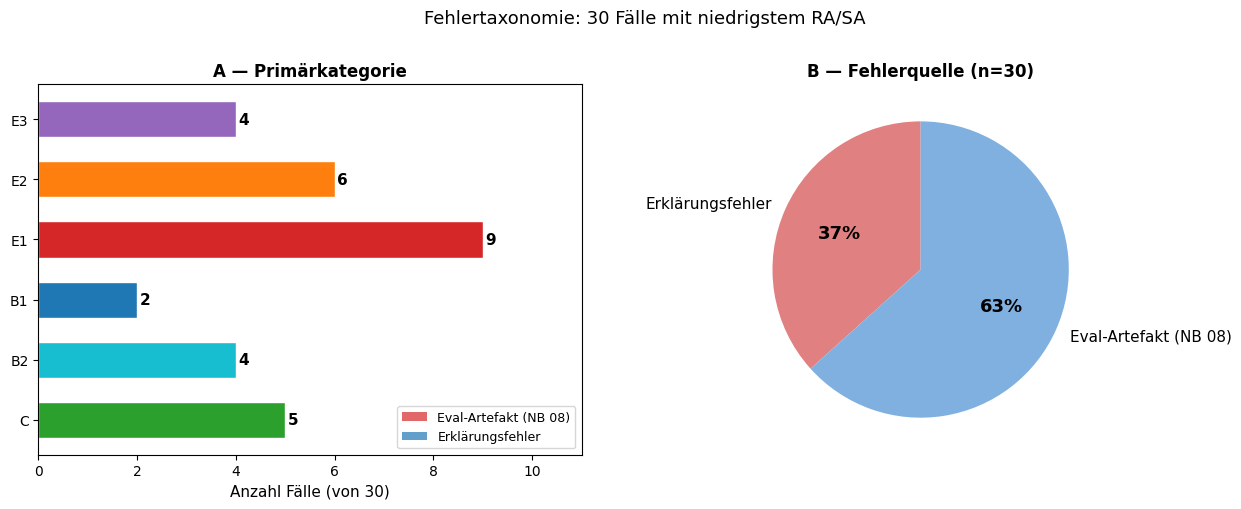

Saved: /Users/anton/Desktop/SoSe26/Belegarbeit/Implementation-XAI-Stahl-ss26/results/error_taxonomy/taxonomy_overview.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Panel A: Frequency by category ---
ax = axes[0]
color_map = {
    'E1': '#d62728', 'E2': '#ff7f0e', 'E3': '#9467bd',
    'B1': '#1f77b4', 'B2': '#17becf', 'C': '#2ca02c',
}
order = ['E3', 'E2', 'E1', 'B1', 'B2', 'C']
counts_ordered = [df_coded['primary'].value_counts().get(c, 0) for c in order]
colors = [color_map[c] for c in order]

bars = ax.barh(order, counts_ordered, color=colors, edgecolor='white', height=0.6)
for bar, cnt in zip(bars, counts_ordered):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            str(cnt), va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Anzahl Fälle (von 30)', fontsize=11)
ax.set_title('A — Primärkategorie', fontsize=12, fontweight='bold')
ax.set_xlim(0, 11)
ax.invert_yaxis()

# Add legend for source
eval_patch = mpatches.Patch(facecolor='#d62728', alpha=0.7, label='Eval-Artefakt (NB 08)')
expl_patch = mpatches.Patch(facecolor='#1f77b4', alpha=0.7, label='Erklärungsfehler')
ax.legend(handles=[eval_patch, expl_patch], loc='lower right', fontsize=9)

# --- Panel B: Source split (pie) ---
ax2 = axes[1]
source_counts = cat_counts.groupby('Quelle')['Anzahl'].sum()
wedges, texts, autotexts = ax2.pie(
    source_counts.values,
    labels=source_counts.index,
    autopct='%1.0f%%',
    colors=['#e08080', '#80b0e0'],
    startangle=90,
    textprops={'fontsize': 11},
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
ax2.set_title('B — Fehlerquelle (n=30)', fontsize=12, fontweight='bold')

plt.suptitle('Fehlertaxonomie: 30 Fälle mit niedrigstem RA/SA', fontsize=13, y=1.01)
plt.tight_layout()

fig_path = os.path.join(out_dir, 'taxonomy_overview.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', fig_path)

## 4  Beispielfälle pro Kategorie

In [6]:
# Load raw artifacts for illustration
with open(os.path.join(BASE, 'results', 'eval08_ichmoukhamedov', 'extractions.json')) as f:
    extractions = json.load(f)

def load_explanation(pipeline_prefix, xai_model, instance_id):
    fname = os.path.join(BASE, 'results', f'pipeline{pipeline_prefix}',
                         f'{xai_model.lower()}_inst{instance_id}.json')
    if os.path.exists(fname):
        with open(fname) as f:
            return json.load(f).get('explanation', '')
    return '(not found)'

def load_shap(xai_model, instance_id):
    fname = os.path.join(BASE, 'explanations',
                         f'local_{xai_model.lower()}_poisson_log_inst{instance_id}.json')
    if os.path.exists(fname):
        with open(fname) as f:
            d = json.load(f)
        return sorted(d['contributions'], key=lambda x: abs(x['contribution']), reverse=True)
    return []

prefix_map = {'JSON→Text': '04', 'Vision': '05', 'Tool-Use': '06'}

def show_case(case_key, label):
    row = df_coded[df_coded['case_key'] == case_key].iloc[0]
    prefix = prefix_map[row['pipeline']]
    shap = load_shap(row['xai'], row['instance'])
    ext  = extractions.get(case_key, {}).get('extraction', {})
    expl = load_explanation(prefix, row['xai'], row['instance'])

    print(f'=== [{label}] {case_key} | RA={row.RA:.2f}, SA={row.SA:.2f} | Primary: {row.primary} ===')
    print(f'Note: {row.note}')
    print()
    print('SHAP Ground Truth (top 4):')
    for c in shap[:4]:
        sign_str = '+' if c['contribution'] > 0 else '-'
        print(f'  rank ? | {c["feature"]:20s} | {sign_str} | |contr|={abs(c["contribution"]):.3f}')
    print()
    print('Extractor Output:')
    sorted_ext = sorted(ext.items(), key=lambda x: x[1].get('rank', 99))
    for feat, info in sorted_ext[:4]:
        print(f'  rank {info.get("rank")} | {feat:20s} | sign={info.get("sign")} | val={info.get("value")}')
    print()
    print('Explanation (first 300 chars):')
    print(expl[:300].replace('\n', ' ') + '...')
    print()

show_case('05_xgb_inst1041', 'E3: Cross-Instance-Halluzination')
show_case('05_xgb_inst1481', 'E2: Vorzeichen-Inversion')
show_case('06_xgb_inst224',  'E1: Feature-Swap')
show_case('05_xgb_inst1677', 'B1: Positiv/Negativ-Gruppierung')
show_case('05_xgb_inst580',  'B2: Nah-Beitrag-Rangswap')
show_case('04_ebm_inst1041', 'C:  yr-Vorzeichenfehler')

=== [E3: Cross-Instance-Halluzination] 05_xgb_inst1041 | RA=0.00, SA=0.00 | Primary: E3 ===
Note: Extractor creates Tuesday-11h context; actual instance is Friday-8h (hr=8 is rank-0 by SHAP). Explanation correctly states hr=8h as strongest driver.

SHAP Ground Truth (top 4):
  rank ? | hr                   | + | |contr|=0.746
  rank ? | yr                   | - | |contr|=0.225
  rank ? | weekday              | + | |contr|=0.194
  rank ? | hum                  | - | |contr|=0.155

Extractor Output:
  rank 0 | weekday              | sign=-1 | val=2
  rank 1 | temp                 | sign=1 | val=0.6585
  rank 2 | yr                   | sign=1 | val=1
  rank 3 | weathersit           | sign=-1 | val=None

Explanation (first 300 chars):
Das Modell sagt für diese Stunde 385 Fahrräder voraus — tatsächlich wurden 387 ausgeliehen. Das ist eine hervorragende Vorhersage mit einer Abweichung von weniger als einem halben Prozent.  Der mit Abstand wichtigste Treiber ist die Uhrzeit 8 Uhr morgens. Der

=== [E2: Vorzeichen-Inversion] 05_xgb_inst1481 | RA=1.00, SA=0.00 | Primary: E2 ===
Note: Rank fully correct (RA=1). Extractor inverts ALL signs: hr(+→-), yr(-→+), all other features similarly flipped. Explanation correctly identifies hr=16h as upward driver.

SHAP Ground Truth (top 4):
  rank ? | hr                   | + | |contr|=0.378
  rank ? | yr                   | - | |contr|=0.260
  rank ? | hum                  | + | |contr|=0.062
  rank ? | mnth                 | + | |contr|=0.062

Extractor Output:
  rank 0 | hr                   | sign=-1 | val=23
  rank 1 | yr                   | sign=1 | val=1
  rank 2 | weekday              | sign=1 | val=5
  rank 3 | mnth                 | sign=-1 | val=4

Explanation (first 300 chars):
Das Modell sagt für diese Stunde 228,6 ausgeliehene Fahrräder voraus, während tatsächlich 277 Räder ausgeliehen wurden. Die Abweichung von rund 48 Rädern bedeutet eine Unterschätzung von etwa 17 % — das ist eine mäßige Treffergenauigkeit. Das Modell erfa

## 5  Kernbefunde

**Eval-Artefakte dominieren:** 19 von 30 Fällen (63 %) sind Fehler des NB-08-Extractors,
nicht der XAI-Pipeline. Das bedeutet, dass die gemessenen RA/SA-Werte die tatsächliche
Erklärungsqualität *unterschätzen*.

**Häufigste Eval-Fehler:**
- **E1 (Feature-Swap, 6 Fälle):** Extractor weist das falsche Feature als Rang 0 zu —
  besonders bei `temp`→`hr` (Instanz 224 in allen Pipelines) und `yr`→`hr` (Instanz 580).
- **E2 (Vorzeichen-Inversion, 6 Fälle):** Extractor kehrt das Vorzeichen um —
  systematisch bei `hr` in Instanz 1481 und 3847 (RA korrekt, SA=0).
- **E3 (Cross-Instance, 4 Fälle):** Extractor halluziniert Kontext aus einer anderen Instanz —
  besonders ausgeprägt bei Instanz 1041 (alle Pipelines).

**Erklärungsfehler (11 Fälle, 37 %):**
- **C (yr-Vorzeichenfehler, 5 Fälle):** LLMs stellen `yr=0` (Jahr 2011, negativer SHAP-Beitrag)
  fälschlich als positives "2012-Wachstum" dar. Systematisch für alle Pipelines bei EBM Instanz 1041
  und Instanz 2510. Prompt-Fix-Kandidat: explizite Anweisung zur SHAP-Vorzeichen-Treue.
- **B1 (Pos/Neg-Gruppierung, 2 Fälle):** Erklärung trennt "Treiber" von "Bremsern",
  statt nach absolutem Beitrag zu sortieren — führt zu RA-Verlust bei nahezu gleichen |Beiträgen|.
- **B2 (Nah-Beitrag-Swap, 4 Fälle):** Features mit ähnlichem |Beitrag| in falscher Reihenfolge.
  Differenzen oft <10 % — schwer durch Prompt-Tuning zu beheben.

**Handlungsempfehlung für Phase 3 (nächster Schritt):** Prompt-Fix für den **yr-Vorzeichenfehler (C)**
— dominante *Erklärungsfehlerklasse*. Konkret: explizite Anweisung, das SHAP-Vorzeichen aus der JSON-
Eingabe zu übernehmen und nicht aus dem Jahreszahl-Kontext zu inferieren.
Die Eval-Artefakte (E1–E3) müssen parallel durch Härtung des NB-08-Extractors adressiert werden
(→ Phase 3, Item "Extraktionsvalidität prüfen").